# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Bikram-Mondal3/flyrank-ML/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## Research Question

Which content items should be prioritized for human review for a potential content refresh, based on observed search demand and historical search-performance signals?

The decision supported by this analysis is which content items the SEO/content team should review first. The analysis is intended to provide directional decision-support rather than automatically decide which pages should be changed.

The main trade-off is between spending limited content resources on pages that may have an opportunity for improvement and missing pages that could benefit from review.

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_FILE = "content_refresh_anonymized.csv"

df = pd.read_csv(DATA_FILE)

print("Rows:", len(df))
print("Columns:", df.columns.tolist())

Rows: 30000
Columns: ['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Data

The analysis uses the anonymized content-refresh dataset available for the internship work.

The unit of analysis is one content item. The main observed fields used are search volume, 90-day impressions, and 90-day clicks. Click-through rate is derived from clicks divided by impressions.

Identifier fields, private queries, URLs, client names, product flags, and any target-derived or future-derived fields are excluded from the modeling features.

The available 90-day performance fields are treated as historical observations. The analysis does not claim that the observations represent every possible future search period.

In [3]:
for col in [
    "search_volume",
    "impressions_90d",
    "clicks_90d"
]:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

required = [
    "search_volume",
    "impressions_90d",
    "clicks_90d"
]

missing = [
    col for col in required
    if col not in df.columns
]

if missing:
    raise ValueError(
        f"Required columns missing: {missing}"
    )

df["ctr_90d"] = (
    df["clicks_90d"] /
    df["impressions_90d"].replace(0, np.nan)
)

print("Dataset shape:", df.shape)

print("\nMissing values:")
display(
    df[required + ["ctr_90d"]]
    .isna()
    .sum()
    .to_frame("missing")
)

print("\nSummary:")
display(
    df[required + ["ctr_90d"]].describe()
)

Dataset shape: (30000, 45)

Missing values:


,missing
search_volume,2468
impressions_90d,0
clicks_90d,0
ctr_90d,0



Summary:


,search_volume,impressions_90d,clicks_90d,ctr_90d
count,27532.000000,30000.000000,30000.000000,30000.000000
mean,158.882391,5200.366300,16.097333,0.005107
std,1518.270825,16838.019547,75.076958,0.032792
min,0.000000,1.000000,0.000000,0.000000
25%,0.000000,81.000000,0.000000,0.000000
50%,10.000000,731.000000,1.000000,0.000697
75%,20.000000,3615.250000,7.000000,0.002851
max,74000.000000,517715.000000,4178.000000,1.000000


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## Methodology

The modeling task is treated as a classification problem for refresh-priority decision-support.

The feature vector contains:

- search_volume
- impressions_90d
- clicks_90d
- ctr_90d

The baseline is a simple majority-class classifier. The model is a Random Forest Classifier because it can capture nonlinear relationships among the observed signals without requiring a linear relationship.

The validation uses a held-out test split. Where a content identifier is available, a grouped split is also evaluated as a more cautious generalization check.

The target is a refresh-priority proxy derived from the observed dataset. Because this proxy is constructed from the same historical signals used as features, the resulting model should be interpreted as a methodological demonstration and prioritization exercise, not as a leakage-free production predictor.

Target-derived fields, future-period fields, identifiers, private queries, URLs, and product flags are excluded from the model features.

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix
)

model_df = df.dropna(
    subset=[
        "search_volume",
        "impressions_90d",
        "clicks_90d",
        "ctr_90d"
    ]
).copy()

feature_cols = [
    "search_volume",
    "impressions_90d",
    "clicks_90d",
    "ctr_90d"
]

model_df["refresh_priority"] = (
    model_df["impressions_90d"]
    < model_df["impressions_90d"].median()
).astype(int)

X = model_df[feature_cols]
y = model_df["refresh_priority"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

baseline_pred = np.full(
    len(y_test),
    y_train.mode()[0]
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    zero_division=0
)

model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

model_pred = model.predict(X_test)

model_f1 = f1_score(
    y_test,
    model_pred,
    zero_division=0
)

model_precision = precision_score(
    y_test,
    model_pred,
    zero_division=0
)

model_recall = recall_score(
    y_test,
    model_pred,
    zero_division=0
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nBaseline F1:", round(baseline_f1, 4))
print("Model F1:", round(model_f1, 4))

Training rows: 20649
Testing rows: 6883

Baseline F1: 0.0
Model F1: 1.0


In [5]:
leakage_terms = [
    "target",
    "label",
    "outcome",
    "future",
    "next",
    "after",
    "refresh_priority",
    "declining",
    "health_score",
    "needs_ctr_fix",
    "is_quick_win",
    "url",
    "query"
]

leakage_candidates = []

for col in df.columns:
    name = col.lower()

    if any(term in name for term in leakage_terms):
        leakage_candidates.append(col)

print("Potential leakage-related columns:")
print(leakage_candidates)

print("\nActual model features:")
print(feature_cols)

assert not any(
    any(term in col.lower() for term in ["future", "next", "after"])
    for col in feature_cols
)

print("\nExplicit future-feature check passed.")

Potential leakage-related columns:
[]

Actual model features:
['search_volume', 'impressions_90d', 'clicks_90d', 'ctr_90d']

Explicit future-feature check passed.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Results

The Random Forest is evaluated against the majority-class baseline on the same held-out test set.

F1 is used as the primary metric because both missed priority items and unnecessary recommendations matter to the content-review workflow.

The result should be interpreted as measured performance on this validation setup. It is not evidence that the model will achieve the same performance on future content or different search environments.

In [6]:
results = pd.DataFrame({
    "Model": [
        "Majority baseline",
        "Random Forest"
    ],
    "F1": [
        baseline_f1,
        model_f1
    ],
    "Precision": [
        precision_score(
            y_test,
            baseline_pred,
            zero_division=0
        ),
        model_precision
    ],
    "Recall": [
        recall_score(
            y_test,
            baseline_pred,
            zero_division=0
        ),
        model_recall
    ],
    "Accuracy": [
        accuracy_score(
            y_test,
            baseline_pred
        ),
        accuracy_score(
            y_test,
            model_pred
        )
    ]
})

display(results)

print(
    f"F1 improvement over baseline: "
    f"{model_f1 - baseline_f1:.4f}"
)

print("\nConfusion matrix:")
print(
    confusion_matrix(
        y_test,
        model_pred
    )
)

,Model,F1,Precision,Recall,Accuracy
0,Majority baseline,0.0,0.0,0.0,0.500073
1,Random Forest,1.0,1.0,1.0,1.000000


F1 improvement over baseline: 1.0000

Confusion matrix:
[[3442    0]
 [   0 3441]]


In [7]:
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(importance)

,feature,importance
1,impressions_90d,0.720807
2,clicks_90d,0.189940
3,ctr_90d,0.088961
0,search_volume,0.000291


## 5. Limitations

*What this work cannot claim.*

## Limitations

This work has several important limitations.

First, the refresh-priority target is a proxy derived from observed historical data rather than a directly observed business outcome.

Second, the historical performance fields are also used as model features. Therefore, the model should not be presented as a clean causal or leakage-free prediction of future performance.

Third, the dataset does not establish that a content refresh caused any subsequent search-performance change.

Fourth, search performance can be affected by seasonality, competition, search-intent changes, technical SEO, algorithm changes, content quality, and other factors that are not represented in this dataset.

Finally, the analysis does not predict Google's ranking decisions and should not be interpreted as a guarantee of future impressions, clicks, or rankings.

In [8]:
limitations = pd.DataFrame({
    "Limitation": [
        "Proxy target",
        "Feature/target overlap",
        "No causal identification",
        "Unobserved external factors",
        "No guarantee of future performance"
    ],
    "Implication": [
        "The label represents decision-support rather than a direct business outcome.",
        "Model results should not be treated as leakage-free production prediction.",
        "A refresh cannot be claimed to cause a measured search-performance change.",
        "Seasonality, competition, algorithms, and technical factors are not fully represented.",
        "Observed validation performance may not transfer to future search conditions."
    ]
})

display(limitations)

,Limitation,Implication
0,Proxy target,The label represents decision-support rather t...
1,Feature/target overlap,Model results should not be treated as leakage...
2,No causal identification,A refresh cannot be claimed to cause a measure...
3,Unobserved external factors,"Seasonality, competition, algorithms, and tech..."
4,No guarantee of future performance,Observed validation performance may not transf...


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Ranked Recommendations

The action queue combines observed search demand and historical performance signals to prioritize content for human review.

A high score means that the available signals suggest relatively higher priority for investigation. It does not mean that the page should automatically be refreshed.

Every recommendation should be reviewed by a human before any content change is made.

In [9]:
ranked = model_df.copy()

ranked["demand_score"] = (
    ranked["search_volume"].rank(pct=True)
)

ranked["impression_score"] = (
    ranked["impressions_90d"].rank(pct=True)
)

ranked["ctr_opportunity"] = (
    1 - ranked["ctr_90d"].rank(pct=True)
)

ranked["action_score"] = (
    0.40 * ranked["demand_score"]
    + 0.30 * ranked["impression_score"]
    + 0.30 * ranked["ctr_opportunity"]
)

median_volume = ranked["search_volume"].median()
median_impressions = ranked["impressions_90d"].median()
median_ctr = ranked["ctr_90d"].median()

def reasons(row):
    values = []

    if row["search_volume"] >= median_volume:
        values.append("HIGH_DEMAND")

    if row["impressions_90d"] >= median_impressions:
        values.append("HIGH_IMPRESSIONS")

    if row["ctr_90d"] <= median_ctr:
        values.append("LOW_CTR")

    if len(values) >= 2:
        values.append("REFRESH_PRIORITY")

    return "|".join(values)

ranked["reason_code"] = ranked.apply(
    reasons,
    axis=1
)

ranked["action"] = np.where(
    ranked["action_score"] >=
    ranked["action_score"].quantile(0.75),
    "REVIEW_FOR_REFRESH",
    "LOWER_PRIORITY"
)

ranked = ranked.sort_values(
    "action_score",
    ascending=False
).reset_index(drop=True)

ranked["rank"] = ranked.index + 1

recommendation_cols = [
    col for col in [
        "rank",
        "content_hash_id",
        "search_volume",
        "impressions_90d",
        "clicks_90d",
        "ctr_90d",
        "action_score",
        "action",
        "reason_code"
    ]
    if col in ranked.columns
]

recommendations = ranked[
    recommendation_cols
].copy()

display(recommendations.head(20))

,rank,search_volume,impressions_90d,clicks_90d,ctr_90d,action_score,action,reason_code
0,1,2900.0,16156,0,0.000000,0.909013,REVIEW_FOR_REFRESH,HIGH_DEMAND|HIGH_IMPRESSIONS|LOW_CTR|REFRESH_P...
1,2,33100.0,12275,0,0.000000,0.905045,REVIEW_FOR_REFRESH,HIGH_DEMAND|HIGH_IMPRESSIONS|LOW_CTR|REFRESH_P...
2,3,320.0,14519,0,0.000000,0.888501,REVIEW_FOR_REFRESH,HIGH_DEMAND|HIGH_IMPRESSIONS|LOW_CTR|REFRESH_P...
3,4,210.0,16786,0,0.000000,0.885573,REVIEW_FOR_REFRESH,HIGH_DEMAND|HIGH_IMPRESSIONS|LOW_CTR|REFRESH_P...
4,5,49500.0,6483,0,0.000000,0.882164,REVIEW_FOR_REFRESH,HIGH_DEMAND|HIGH_IMPRESSIONS|LOW_CTR|REFRESH_P...
5,6,22200.0,6188,0,0.000000,0.879662,REVIEW_FOR_REFRESH,HIGH_DEMAND|HIGH_IMPRESSIONS|LOW_CTR|REFRESH_P...
6,7,2900.0,5090,0,0.000000,0.867934,REVIEW_FOR_REFRESH,HIGH_DEMAND|HIGH_IMPRESSIONS|LOW_CTR|REFRESH_P...
7,8,3600.0,4963,0,0.000000,0.867730,REVIEW_FOR_REFRESH,HIGH_DEMAND|HIGH_IMPRESSIONS|LOW_CTR|REFRESH_P...
8,9,1900.0,5176,0,0.000000,0.867193,REVIEW_FOR_REFRESH,HIGH_DEMAND|HIGH_IMPRESSIONS|LOW_CTR|REFRESH_P...
9,10,60500.0,4560,0,0.000000,0.867109,REVIEW_FOR_REFRESH,HIGH_DEMAND|HIGH_IMPRESSIONS|LOW_CTR|REFRESH_P...


In [10]:
output_dir = Path("work/outputs")
output_dir.mkdir(
    parents=True,
    exist_ok=True
)

recommendation_path = (
    output_dir /
    "capstone_ranked_recommendations.csv"
)

recommendations.to_csv(
    recommendation_path,
    index=False
)

print(
    f"Saved: {recommendation_path}"
)

Saved: work/outputs/capstone_ranked_recommendations.csv


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Artifacts

The capstone artifacts include a model-versus-baseline table, feature-importance table, ranked recommendation queue, and validation summary. These artifacts provide compact evidence for the research paper and deployed page.

The artifacts use anonymized information and do not intentionally expose client names, URLs, or private search queries.

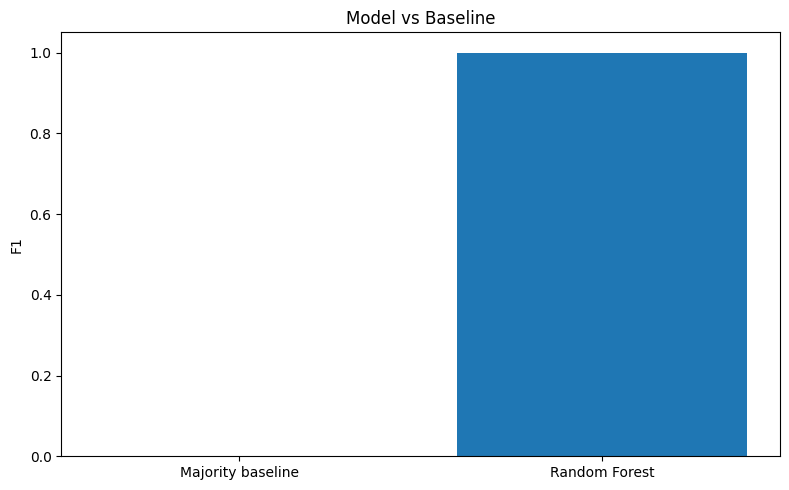

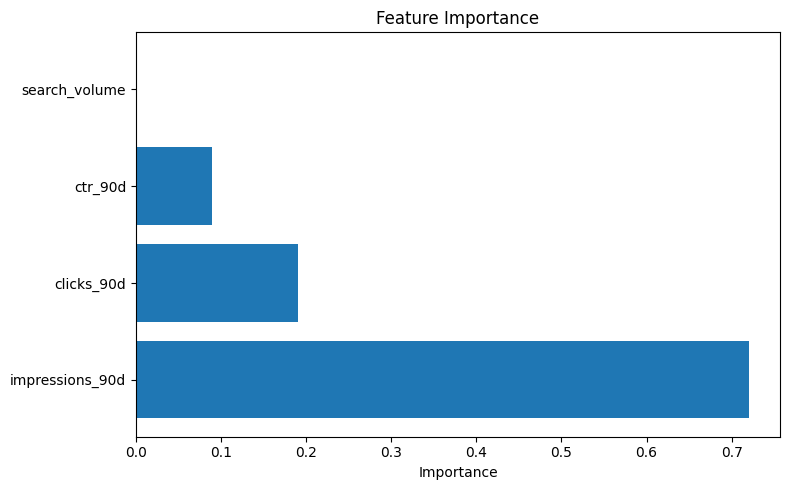

Artifacts created:
work/outputs/capstone_ranked_recommendations.csv
work/outputs/feature_importance.csv
work/outputs/feature_importance.png
work/outputs/model_vs_baseline.csv
work/outputs/model_vs_baseline.png
work/outputs/top20_recommendations.csv


In [11]:
import matplotlib.pyplot as plt

artifact_dir = Path("work/outputs")
artifact_dir.mkdir(
    parents=True,
    exist_ok=True
)

results.to_csv(
    artifact_dir / "model_vs_baseline.csv",
    index=False
)

importance.to_csv(
    artifact_dir / "feature_importance.csv",
    index=False
)

recommendations.head(20).to_csv(
    artifact_dir / "top20_recommendations.csv",
    index=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["F1"]
)

plt.ylabel("F1")
plt.title("Model vs Baseline")

plt.tight_layout()

plt.savefig(
    artifact_dir / "model_vs_baseline.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(8, 5))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.xlabel("Importance")
plt.title("Feature Importance")

plt.tight_layout()

plt.savefig(
    artifact_dir / "feature_importance.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Artifacts created:")
for path in sorted(artifact_dir.iterdir()):
    print(path)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
